# Black-Scholes Option Pricer — Interactive Explorer

Use the sliders to change inputs. All prices, Greeks and charts update live.

**Conventions (enforced throughout):**
- Theta: negative, per calendar day (÷365)
- Vega: per 1% move in vol
- Rho: per 1% move in rate
- No dividends; European options only

In [13]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, clear_output

from pricer.black_scholes import black_scholes_price, black_scholes_greeks
from pricer.implied_vol import implied_vol, IVSolverError

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

## 1 — Pricer: price + all Greeks

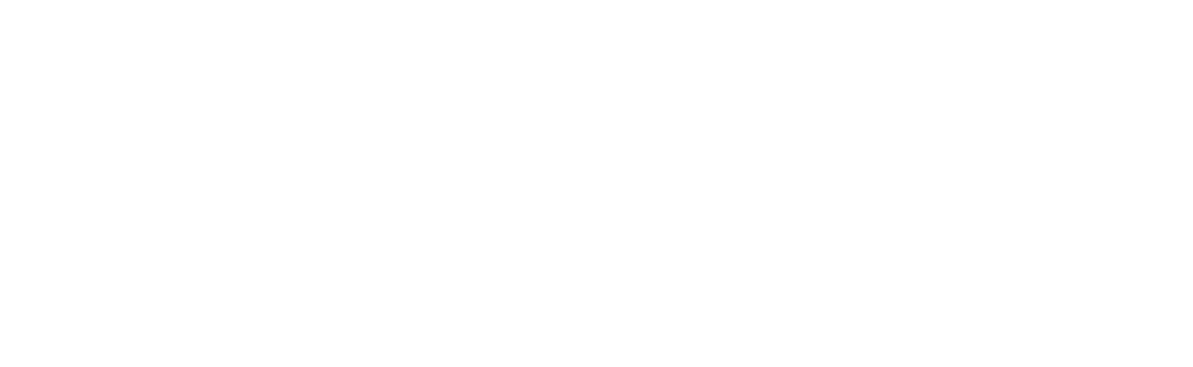

In [14]:
# ── Sliders ────────────────────────────────────────────────────────────────
w_spot   = widgets.FloatSlider(value=100, min=50,   max=200,  step=1,    description='Spot')
w_strike = widgets.FloatSlider(value=100, min=50,   max=200,  step=1,    description='Strike')
w_vol    = widgets.FloatSlider(value=0.20, min=0.01, max=1.00, step=0.01, description='Vol', readout_format='.0%')
w_rate   = widgets.FloatSlider(value=0.05, min=-0.02, max=0.20, step=0.005, description='Rate', readout_format='.1%')
w_time   = widgets.FloatSlider(value=1.0,  min=0.02, max=5.0,  step=0.05,  description='Time (y)')
w_type   = widgets.ToggleButtons(value='call', options=['call', 'put'], description='Type')

out_price = widgets.Output()

def update_pricer(*_):
    spot, strike, vol, rate, T, otype = (
        w_spot.value, w_strike.value, w_vol.value,
        w_rate.value, w_time.value,   w_type.value
    )
    price   = black_scholes_price(spot, strike, vol, rate, T, otype)
    greeks  = black_scholes_greeks(spot, strike, vol, rate, T, otype)
    intrinsic = max(spot - strike, 0) if otype == 'call' else max(strike - spot, 0)

    with out_price:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

        # ── Left: price breakdown bar ──────────────────────────────────────
        ax = axes[0]
        colour = '#2563EB' if otype == 'call' else '#DC2626'
        ax.bar(['Intrinsic', 'Time value', 'Total price'],
               [intrinsic, price - intrinsic, price],
               color=[colour + '99', colour + 'BB', colour],
               edgecolor=colour, linewidth=0.8)
        for bar_x, val in zip([0, 1, 2], [intrinsic, price - intrinsic, price]):
            ax.text(bar_x, val + 0.05, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
        ax.set_ylabel('Value ($)')
        ax.set_title(f'European {otype.upper()} — Price Breakdown')
        ax.set_ylim(bottom=0)

        # ── Right: Greeks table ────────────────────────────────────────────
        ax2 = axes[1]
        ax2.axis('off')
        rows = [
            ['Greek',          'Value',                'Interpretation'],
            ['Delta',          f"{greeks['delta']:+.4f}",  'P&L per $1 move in spot'],
            ['Gamma',          f"{greeks['gamma']:+.4f}",  'Delta change per $1 move'],
            ['Vega (per 1%)',   f"{greeks['vega']:+.4f}",  'P&L per 1% vol move'],
            ['Theta (per day)', f"{greeks['theta']:+.4f}", 'Daily time decay (negative)'],
            ['Rho (per 1%)',    f"{greeks['rho']:+.4f}",   'P&L per 1% rate move'],
        ]
        tbl = ax2.table(cellText=rows[1:], colLabels=rows[0],
                        loc='center', cellLoc='center')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9.5)
        tbl.scale(1, 1.6)
        ax2.set_title(f'Greeks   (S={spot}, K={strike}, σ={vol:.0%}, r={rate:.1%}, T={T}y)')

        plt.tight_layout()
        plt.show()

for w in [w_spot, w_strike, w_vol, w_rate, w_time, w_type]:
    w.observe(update_pricer, names='value')

display(
    widgets.VBox([
        widgets.HBox([w_spot, w_strike]),
        widgets.HBox([w_vol,  w_rate]),
        widgets.HBox([w_time, w_type]),
    ]),
    out_price
)
update_pricer()

## 2 — Payoff diagram

Output()

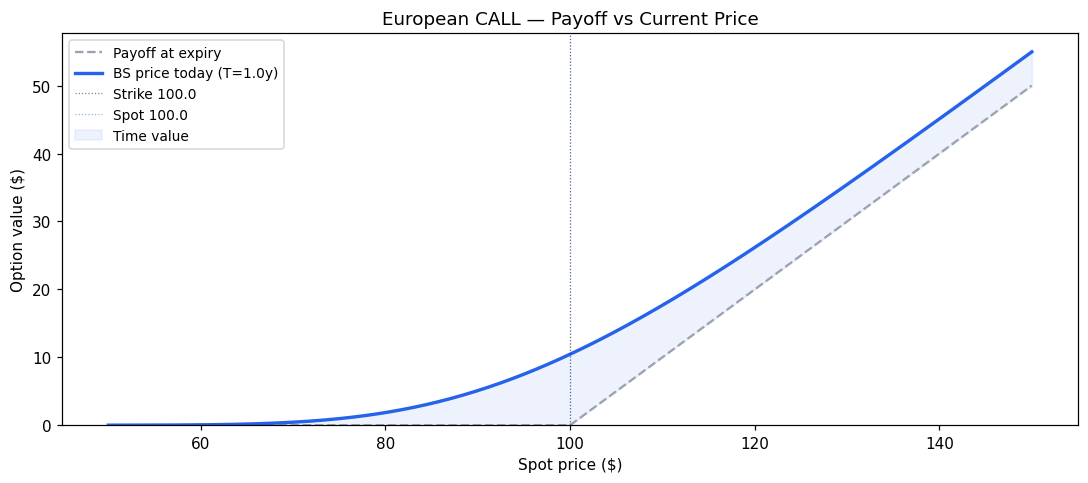

In [15]:
w2_spot   = widgets.FloatSlider(value=100, min=50,  max=200,  step=1,    description='Spot')
w2_strike = widgets.FloatSlider(value=100, min=50,  max=200,  step=1,    description='Strike')
w2_vol    = widgets.FloatSlider(value=0.20, min=0.01, max=1.0, step=0.01, description='Vol', readout_format='.0%')
w2_rate   = widgets.FloatSlider(value=0.05, min=-0.02, max=0.20, step=0.005, description='Rate', readout_format='.1%')
w2_time   = widgets.FloatSlider(value=1.0, min=0.02, max=5.0, step=0.05, description='Time (y)')
w2_type   = widgets.ToggleButtons(value='call', options=['call', 'put'], description='Type')

out_payoff = widgets.Output()

def update_payoff(*_):
    spot, strike, vol, rate, T, otype = (
        w2_spot.value, w2_strike.value, w2_vol.value,
        w2_rate.value, w2_time.value,   w2_type.value
    )
    spots = np.linspace(spot * 0.5, spot * 1.5, 300)
    payoff   = np.maximum(spots - strike, 0) if otype == 'call' else np.maximum(strike - spots, 0)
    bs_today = np.array([black_scholes_price(s, strike, vol, rate, T, otype) for s in spots])
    colour   = '#2563EB' if otype == 'call' else '#DC2626'

    with out_payoff:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(spots, payoff,   color='#9CA3AF', lw=1.5, ls='--', label='Payoff at expiry')
        ax.plot(spots, bs_today, color=colour,    lw=2.2, label=f'BS price today (T={T}y)')
        ax.axvline(strike, color='black', lw=0.8, ls=':', alpha=0.5, label=f'Strike {strike}')
        ax.axvline(spot,   color=colour,  lw=0.8, ls=':', alpha=0.5, label=f'Spot {spot}')
        ax.fill_between(spots, payoff, bs_today, alpha=0.08, color=colour, label='Time value')
        ax.set_xlabel('Spot price ($)')
        ax.set_ylabel('Option value ($)')
        ax.set_title(f'European {otype.upper()} — Payoff vs Current Price')
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

for w in [w2_spot, w2_strike, w2_vol, w2_rate, w2_time, w2_type]:
    w.observe(update_payoff, names='value')

display(
    widgets.VBox([
        widgets.HBox([w2_spot, w2_strike]),
        widgets.HBox([w2_vol,  w2_rate]),
        widgets.HBox([w2_time, w2_type]),
    ]),
    out_payoff
)
update_payoff()

## 3 — Greeks vs Spot

Output()

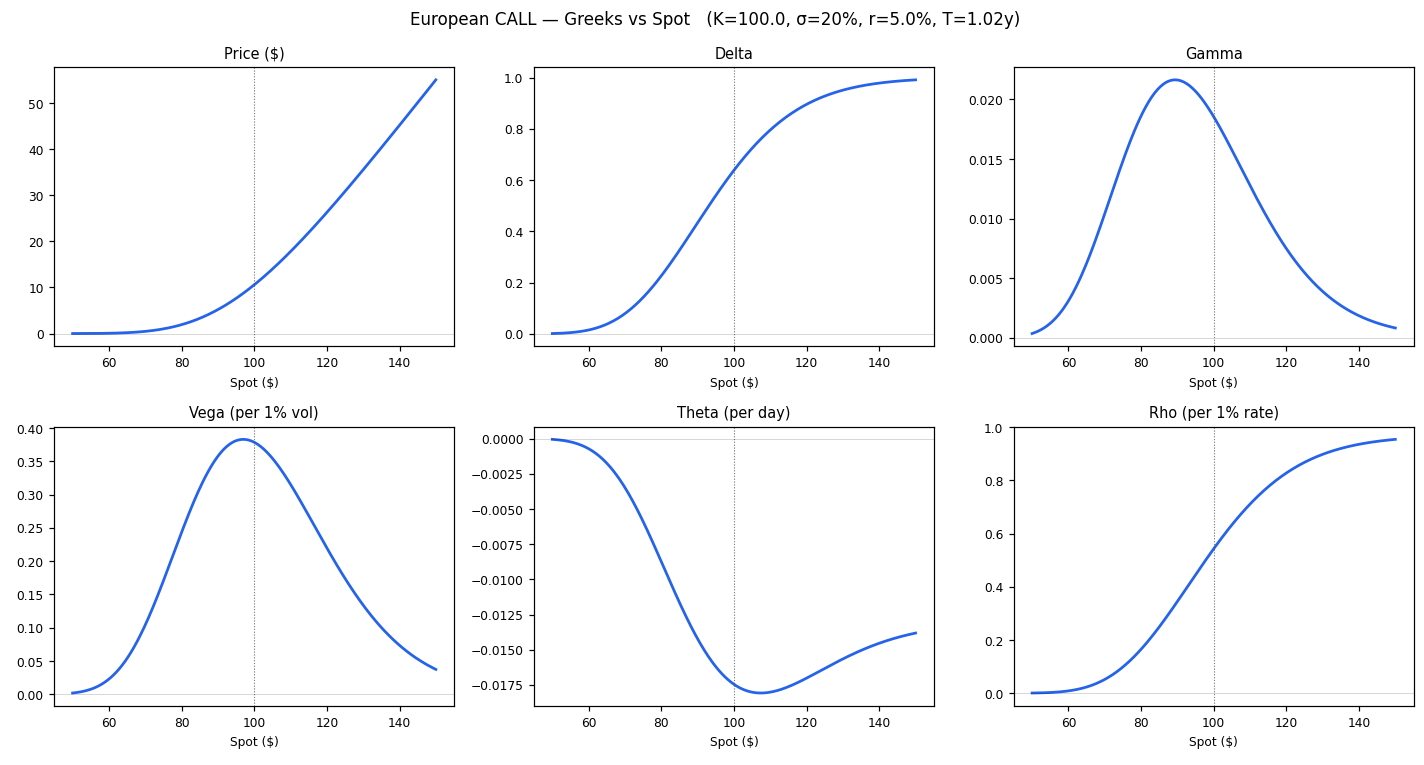

In [16]:
w3_spot   = widgets.FloatSlider(value=100, min=50,  max=200,  step=1,    description='Spot')
w3_strike = widgets.FloatSlider(value=100, min=50,  max=200,  step=1,    description='Strike')
w3_vol    = widgets.FloatSlider(value=0.20, min=0.01, max=1.0, step=0.01, description='Vol', readout_format='.0%')
w3_rate   = widgets.FloatSlider(value=0.05, min=-0.02, max=0.20, step=0.005, description='Rate', readout_format='.1%')
w3_time   = widgets.FloatSlider(value=1.0, min=0.02, max=5.0, step=0.05, description='Time (y)')
w3_type   = widgets.ToggleButtons(value='call', options=['call', 'put'], description='Type')

out_greeks = widgets.Output()

GREEK_META = [
    ('price', 'Price ($)'),
    ('delta', 'Delta'),
    ('gamma', 'Gamma'),
    ('vega',  'Vega (per 1% vol)'),
    ('theta', 'Theta (per day)'),
    ('rho',   'Rho (per 1% rate)'),
]

def update_greeks(*_):
    spot, strike, vol, rate, T, otype = (
        w3_spot.value, w3_strike.value, w3_vol.value,
        w3_rate.value, w3_time.value,   w3_type.value
    )
    spots  = np.linspace(spot * 0.5, spot * 1.5, 250)
    colour = '#2563EB' if otype == 'call' else '#DC2626'

    def series(metric):
        if metric == 'price':
            return [black_scholes_price(s, strike, vol, rate, T, otype) for s in spots]
        return [black_scholes_greeks(s, strike, vol, rate, T, otype)[metric] for s in spots]

    with out_greeks:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 3, figsize=(13, 7))
        fig.suptitle(
            f'European {otype.upper()} — Greeks vs Spot   '
            f'(K={strike}, σ={vol:.0%}, r={rate:.1%}, T={T}y)',
            fontsize=11
        )
        for ax, (metric, label) in zip(axes.flat, GREEK_META):
            ax.plot(spots, series(metric), color=colour, lw=1.8)
            ax.axvline(strike, color='black', lw=0.7, ls=':', alpha=0.5)
            ax.axvline(spot,   color='grey',  lw=0.7, ls=':', alpha=0.5)
            ax.axhline(0,      color='black', lw=0.4, alpha=0.25)
            ax.set_title(label, fontsize=9.5)
            ax.set_xlabel('Spot ($)', fontsize=8)
            ax.tick_params(labelsize=8)
        plt.tight_layout()
        plt.show()

for w in [w3_spot, w3_strike, w3_vol, w3_rate, w3_time, w3_type]:
    w.observe(update_greeks, names='value')

display(
    widgets.VBox([
        widgets.HBox([w3_spot, w3_strike]),
        widgets.HBox([w3_vol,  w3_rate]),
        widgets.HBox([w3_time, w3_type]),
    ]),
    out_greeks
)
update_greeks()

## 4 — Implied Volatility solver

In [17]:
w4_price  = widgets.FloatText(value=10.45, description='Market price', style={'description_width':'120px'})
w4_spot   = widgets.FloatText(value=100,   description='Spot')
w4_strike = widgets.FloatText(value=100,   description='Strike')
w4_rate   = widgets.FloatText(value=0.05,  description='Rate')
w4_time   = widgets.FloatText(value=1.0,   description='Time (y)')
w4_type   = widgets.ToggleButtons(value='call', options=['call', 'put'], description='Type')
btn_solve = widgets.Button(description='Solve IV', button_style='primary')
out_iv    = widgets.Output()

def solve_iv(_):
    with out_iv:
        clear_output(wait=True)
        try:
            iv = implied_vol(
                market_price   = w4_price.value,
                spot           = w4_spot.value,
                strike         = w4_strike.value,
                rate           = w4_rate.value,
                time_to_expiry = w4_time.value,
                option_type    = w4_type.value,
            )
            bs_check = black_scholes_price(
                w4_spot.value, w4_strike.value, iv,
                w4_rate.value, w4_time.value, w4_type.value
            )
            print(f'Implied vol : {iv:.4%}')
            print(f'BS price check : {bs_check:.4f}  (market: {w4_price.value:.4f})')
            print(f'Residual       : {abs(bs_check - w4_price.value):.2e}')

            # Plot IV smile: vary strike, solve IV at each
            strikes = np.linspace(w4_spot.value * 0.7, w4_spot.value * 1.3, 60)
            prices  = [black_scholes_price(w4_spot.value, k, iv,
                                           w4_rate.value, w4_time.value, w4_type.value)
                       for k in strikes]
            ivs = []
            for k, p in zip(strikes, prices):
                try:
                    ivs.append(implied_vol(p, w4_spot.value, k,
                                          w4_rate.value, w4_time.value, w4_type.value))
                except IVSolverError:
                    ivs.append(float('nan'))

            fig, ax = plt.subplots(figsize=(8, 3.5))
            ax.plot(strikes, np.array(ivs) * 100, color='#7C3AED', lw=2)
            ax.axvline(w4_spot.value,   color='grey',  lw=0.8, ls=':', label='Spot')
            ax.axvline(w4_strike.value, color='black', lw=0.8, ls=':', label='Input strike')
            ax.axhline(iv * 100, color='#7C3AED', lw=0.8, ls='--', alpha=0.5, label=f'Solved IV {iv:.1%}')
            ax.set_xlabel('Strike ($)')
            ax.set_ylabel('Implied vol (%)')
            ax.set_title('Flat IV smile (BS model has no skew by construction)')
            ax.legend(fontsize=9)
            plt.tight_layout()
            plt.show()

        except (IVSolverError, ValueError) as e:
            print(f'Error: {e}')

btn_solve.on_click(solve_iv)

display(
    widgets.VBox([
        widgets.HBox([w4_price, w4_type]),
        widgets.HBox([w4_spot, w4_strike]),
        widgets.HBox([w4_rate, w4_time]),
        btn_solve,
    ]),
    out_iv
)

Output()

## 6 — Live market data: real IV smile vs Black-Scholes

Fetches the live options chain for any ticker via **yfinance** (no API key needed).
We solve our own implied vol on each strike using the mid-price, then plot the
real vol smile alongside the flat BS assumption.

**Why the smile matters:** BS assumes constant vol across all strikes. In reality,
OTM puts trade at higher IV than ATM options (the skew), which is why vol surfaces
and smile models (SABR, SVI) exist. This chart makes that failure visible.

In [18]:
import yfinance as yf
import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Inputs ─────────────────────────────────────────────────────────────────
w6_ticker      = widgets.Text(value='AAPL', description='Ticker',
                               layout=widgets.Layout(width='160px'))
w6_rate        = widgets.FloatSlider(value=0.043, min=0.0, max=0.10, step=0.001,
                                      description='Risk-free rate',
                                      readout_format='.1%',
                                      style={'description_width': '120px'},
                                      layout=widgets.Layout(width='380px'))
w6_option_type = widgets.ToggleButtons(value='call', options=['call', 'put'],
                                        description='Type')
w6_expiry      = widgets.Dropdown(description='Expiry',
                                   style={'description_width': '60px'},
                                   layout=widgets.Layout(width='220px'))
btn_fetch      = widgets.Button(description='Fetch live data',
                                 button_style='success', icon='download')
out_live       = widgets.Output()
lbl_status     = widgets.Label(value='Enter a ticker and click Fetch.')

# Cache so we don't re-download on expiry/type/rate changes
_cache = {}

def fetch_ticker(_):
    ticker = w6_ticker.value.strip().upper()
    lbl_status.value = f'Fetching {ticker}...'
    with out_live:
        clear_output(wait=True)
    try:
        tk      = yf.Ticker(ticker)
        spot    = tk.fast_info['lastPrice']
        expiries = tk.options
        if not expiries:
            lbl_status.value = f'No options data found for {ticker}.'
            return
        _cache['tk']     = tk
        _cache['spot']   = spot
        _cache['ticker'] = ticker
        w6_expiry.options = expiries
        w6_expiry.value   = expiries[0]
        lbl_status.value  = (f'{ticker}  |  Live spot: ${spot:.2f}  '
                              f'|  {len(expiries)} expiries available')
        plot_smile(None)
    except Exception as e:
        lbl_status.value = f'Error: {e}'

def plot_smile(_):
    if 'tk' not in _cache:
        return
    tk     = _cache['tk']
    spot   = _cache['spot']
    ticker = _cache['ticker']
    expiry = w6_expiry.value
    rate   = w6_rate.value
    otype  = w6_option_type.value

    # Time to expiry in years (minimum 1 day to avoid division issues)
    expiry_date = datetime.date.fromisoformat(expiry)
    T = max((expiry_date - datetime.date.today()).days, 1) / 365.0

    chain = tk.option_chain(expiry)
    df    = chain.calls if otype == 'call' else chain.puts

    # Mid-price; skip rows with zero or missing bid/ask
    df = df[(df['bid'] > 0) & (df['ask'] > 0)].copy()
    df['mid'] = (df['bid'] + df['ask']) / 2.0

    # Keep strikes within ±40% of spot — far wings have unreliable prices
    df = df[(df['strike'] >= spot * 0.60) & (df['strike'] <= spot * 1.40)]

    if df.empty:
        with out_live:
            clear_output(wait=True)
            print('No usable strikes within ±40% of spot for this expiry.')
        return

    # Solve IV for each strike using our own pricer (not Yahoo's number)
    solved_strikes, solved_ivs = [], []
    for _, row in df.iterrows():
        try:
            iv = implied_vol(row['mid'], spot, row['strike'], rate, T, otype)
            solved_strikes.append(row['strike'])
            solved_ivs.append(iv * 100)
        except (IVSolverError, ValueError):
            pass  # skip strikes where no valid IV exists

    if not solved_strikes:
        with out_live:
            clear_output(wait=True)
            print('Could not solve IV for any strike. Try a different expiry.')
        return

    # ATM vol = strike closest to spot
    atm_idx    = min(range(len(solved_strikes)), key=lambda i: abs(solved_strikes[i] - spot))
    atm_iv_pct = solved_ivs[atm_idx]

    # Skew metrics
    otm_ivs  = [iv for s, iv in zip(solved_strikes, solved_ivs) if s < spot * 0.95]
    call_ivs = [iv for s, iv in zip(solved_strikes, solved_ivs) if s > spot * 1.05]
    skew     = (np.mean(otm_ivs) - atm_iv_pct) if otm_ivs else float('nan')

    with out_live:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # ── Left: IV smile chart ───────────────────────────────────────────
        colour = '#2563EB' if otype == 'call' else '#DC2626'
        ax = axes[0]
        ax.plot(solved_strikes, solved_ivs, 'o-', color=colour, lw=2,
                markersize=5, label=f'Market IV ({otype}s, mid-price)')
        ax.axhline(atm_iv_pct, color='#6B7280', lw=1.4, ls='--',
                   label=f'BS flat vol = {atm_iv_pct:.1f}% (ATM)')
        ax.axvline(spot, color='black', lw=0.9, ls=':', alpha=0.6,
                   label=f'Spot ${spot:.2f}')
        ax.fill_between(solved_strikes, atm_iv_pct, solved_ivs,
                        alpha=0.10, color=colour, label='Smile premium over BS')
        ax.set_xlabel('Strike ($)')
        ax.set_ylabel('Implied volatility (%)')
        ax.set_title(
            f'{ticker} — Real IV Smile vs Flat Black-Scholes\n'
            f'Expiry {expiry}  (T = {T:.3f}y,  {int(T*365)} days)'
        )
        ax.legend(fontsize=8.5)

        # ── Right: summary table ───────────────────────────────────────────
        ax2 = axes[1]
        ax2.axis('off')
        rows = [
            ['Metric',           'Value'],
            ['Ticker',           ticker],
            ['Live spot',        f'${spot:.2f}'],
            ['Expiry',           expiry],
            ['Days to expiry',   str(int(T * 365))],
            ['Risk-free rate',   f'{rate:.1%}'],
            ['ATM IV',           f'{atm_iv_pct:.1f}%'],
            ['OTM put avg IV',   f'{np.mean(otm_ivs):.1f}%' if otm_ivs  else 'n/a'],
            ['OTM call avg IV',  f'{np.mean(call_ivs):.1f}%' if call_ivs else 'n/a'],
            ['Put skew (OTM-ATM)', f'{skew:+.1f}%' if not np.isnan(skew) else 'n/a'],
            ['Strikes solved',   str(len(solved_strikes))],
            ['BS assumption',    'Flat vol (no skew)'],
        ]
        tbl = ax2.table(cellText=rows[1:], colLabels=rows[0],
                        loc='center', cellLoc='left')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9.5)
        tbl.scale(1.2, 1.65)
        ax2.set_title('Market snapshot', fontsize=11)

        plt.tight_layout()
        plt.show()

btn_fetch.on_click(fetch_ticker)
w6_expiry.observe(plot_smile,      names='value')
w6_option_type.observe(plot_smile, names='value')
w6_rate.observe(plot_smile,        names='value')

display(
    widgets.VBox([
        widgets.HBox([w6_ticker, btn_fetch, w6_option_type]),
        widgets.HBox([w6_expiry, w6_rate]),
        lbl_status,
    ]),
    out_live
)

Task was destroyed but it is pending!
task: <Task pending name='Task-341' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\ainho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-342' coro=<Kernel.shell_main() running at C:\Users\ainho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\ainho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\ainho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arrays\arrow\__init__.py:5: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from pandas.core.arrays.arrow.array import ArrowExtensionArray
Task was destroyed but it is pending!
task: <Task pending name='Task-342' coro=<Kernel.shell_main() running at C:\Users\ainho\AppData\Local\Python\pythoncore-3

Output()

## 5 — Price surface (spot × vol)

Output()

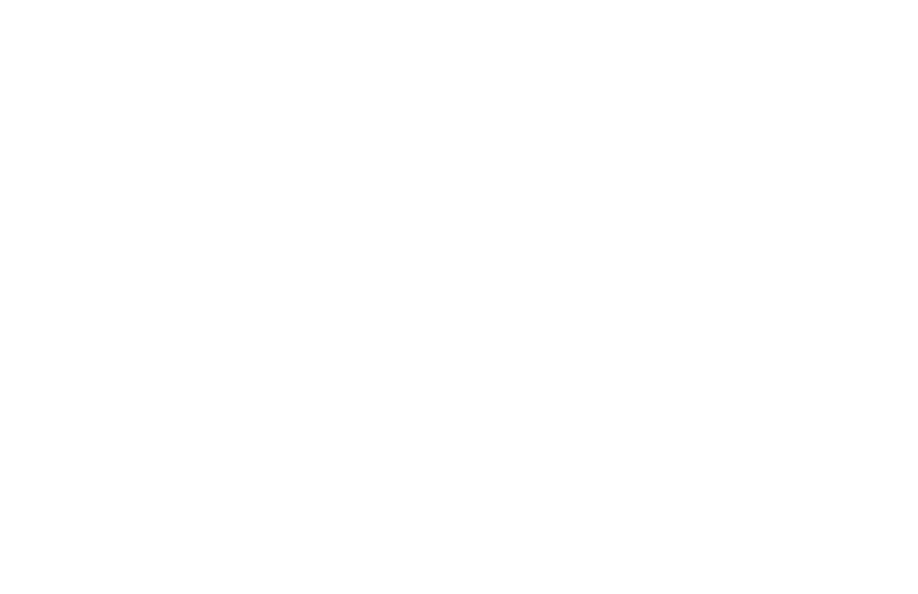

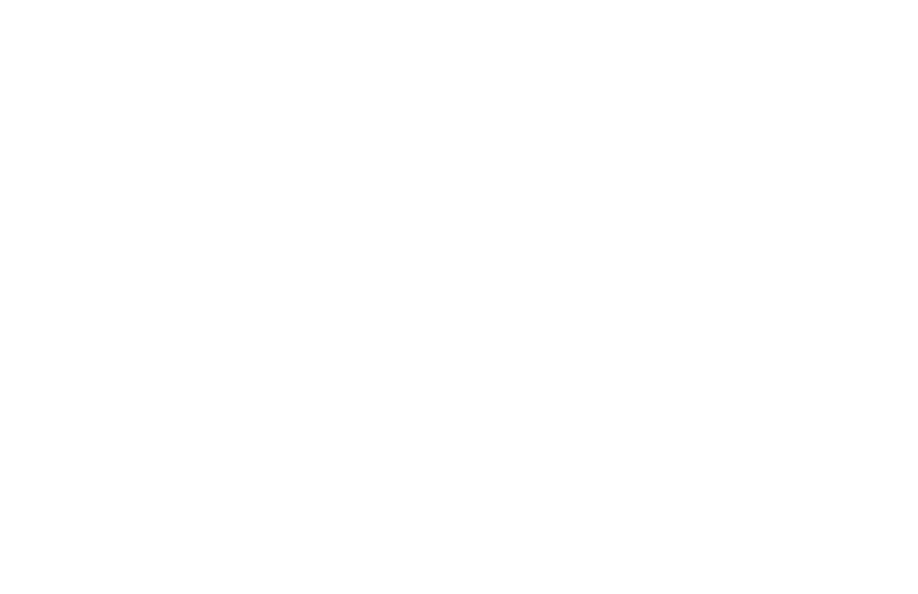

In [19]:
w5_strike = widgets.FloatSlider(value=100, min=50, max=200, step=5,     description='Strike')
w5_rate   = widgets.FloatSlider(value=0.05, min=-0.02, max=0.20, step=0.005, description='Rate', readout_format='.1%')
w5_time   = widgets.FloatSlider(value=1.0,  min=0.05, max=5.0,  step=0.05,  description='Time (y)')
w5_type   = widgets.ToggleButtons(value='call', options=['call', 'put'], description='Type')

out_surface = widgets.Output()

def update_surface(*_):
    strike, rate, T, otype = (
        w5_strike.value, w5_rate.value, w5_time.value, w5_type.value
    )
    spots = np.linspace(strike * 0.6, strike * 1.4, 60)
    vols  = np.linspace(0.05, 0.80, 60)
    grid  = np.array([
        [black_scholes_price(s, strike, v, rate, T, otype) for s in spots]
        for v in vols
    ])

    with out_surface:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 5.5))
        mesh = ax.pcolormesh(spots, vols * 100, grid, cmap='RdYlGn', shading='auto')
        cb = fig.colorbar(mesh, ax=ax)
        cb.set_label('Option price ($)', fontsize=9)
        ax.axvline(strike, color='white', lw=1.2, ls='--', alpha=0.8, label=f'Strike {strike}')
        ax.set_xlabel('Spot price ($)')
        ax.set_ylabel('Implied volatility (%)')
        ax.set_title(f'European {otype.upper()} Price Surface   (K={strike}, r={rate:.1%}, T={T}y)')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

for w in [w5_strike, w5_rate, w5_time, w5_type]:
    w.observe(update_surface, names='value')

display(
    widgets.VBox([
        widgets.HBox([w5_strike, w5_type]),
        widgets.HBox([w5_rate,   w5_time]),
    ]),
    out_surface
)
update_surface()